In [4]:
# Cell 1 - Initialization

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../model')

from evidential_mlp import EvidentialMLP
from rssm import SimplifiedRSSM

import importlib, sys
# Remove cached module so it reimports from disk
for mod in list(sys.modules.keys()):
    if 'evidential_mlp' in mod:
        del sys.modules[mod]

# Load processed dataset
df = pd.read_parquet('../data/processed.parquet')
trajs = pd.read_parquet('../data/trajectories.parquet')

# Load checkpoints
mlp_ckpt  = torch.load('../model/checkpoint.pt',      weights_only=False)
rssm_ckpt = torch.load('../model/rssm_checkpoint.pt', weights_only=False)

print(f'Dataset: {len(df)} points, {len(trajs.traj_id.unique())} trajectories')
print(f'Regimes: {df.regime.value_counts().to_dict()}')

Dataset: 200 points, 300 trajectories
Regimes: {'continuum': 100, 'transitional': 86, 'free_molecular': 14}


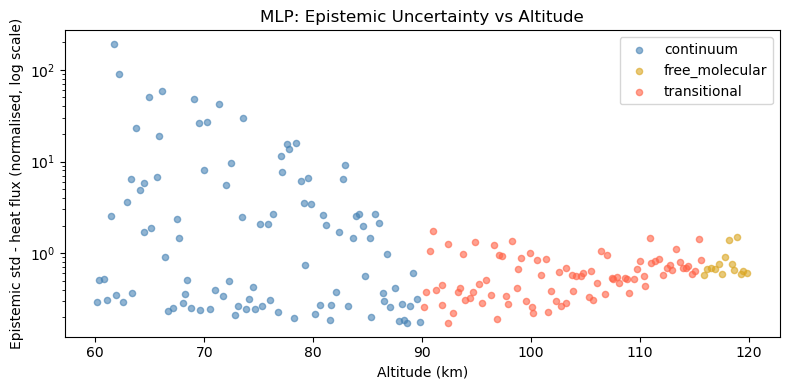

In [5]:
# Cell 2 - MLP Epistemic Uncertainty

mlp = EvidentialMLP(in_dim=4)
mlp.load_state_dict(mlp_ckpt['model'])
mlp.eval()

X_mean = mlp_ckpt['X_mean']
X_std  = mlp_ckpt['X_std']

X_raw = df[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
X = torch.tensor((X_raw - X_mean) / X_std)

with torch.no_grad():
    mu, v, alpha, beta = mlp(X)
    ep_var = beta / (v * (alpha - 1).clamp(min=1e-4))
    ep_std = ep_var.sqrt().numpy()

df['ep_std_q_mlp'] = ep_std[:, 2]   # q is index 2

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'continuum': 'steelblue', 'transitional': 'tomato', 'free_molecular': 'goldenrod'}
for regime, grp in df.groupby('regime'):
    ax.scatter(grp['altitude_km'], grp['ep_std_q_mlp'],
               label=regime, color=colors[regime], alpha=0.6, s=20)
ax.set_xlabel('Altitude (km)')
ax.set_yscale('log')
ax.set_ylabel('Epistemic std - heat flux (normalised, log scale)')
ax.set_title('MLP: Epistemic Uncertainty vs Altitude')
ax.legend()
plt.tight_layout()
plt.savefig('../data/mlp_uncertainty_vs_altitude.png', dpi=150)
plt.show()

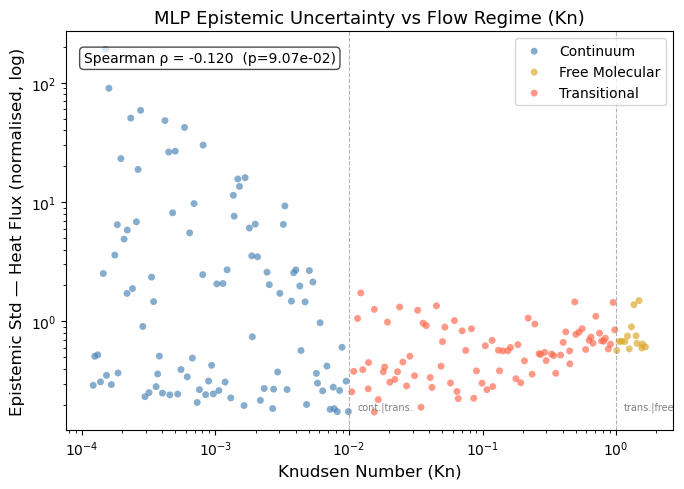

Spearman rho=-0.120, p=9.07e-02


In [6]:
# Cell 3 - MLP Epistemic Uncertainty vs Knudsen Number

from scipy.stats import spearmanr

colors = {'continuum': 'steelblue', 'transitional': 'tomato', 'free_molecular': 'goldenrod'}

fig, ax = plt.subplots(figsize=(7, 5))

for regime, grp in df.groupby('regime'):
    ax.scatter(grp['Kn'], grp['ep_std_q_mlp'],
               label=regime.replace('_', ' ').title(),
               color=colors[regime], alpha=0.65, s=25, edgecolors='none')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Knudsen Number (Kn)', fontsize=12)
ax.set_ylabel('Epistemic Std — Heat Flux (normalised, log)', fontsize=12)
ax.set_title('MLP Epistemic Uncertainty vs Flow Regime (Kn)', fontsize=13)
ax.legend(fontsize=10)

ax.axvline(0.01, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(1.0,  color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(0.01*1.15, ax.get_ylim()[0]*1.5, 'cont.|trans.', fontsize=7, color='gray')
ax.text(1.0 *1.15, ax.get_ylim()[0]*1.5, 'trans.|free',  fontsize=7, color='gray')

rho, pval = spearmanr(df['Kn'], df['ep_std_q_mlp'])
ax.text(0.03, 0.95, f'Spearman ρ = {rho:.3f}  (p={pval:.2e})',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/mlp_uncertainty_vs_kn.png', dpi=150)
plt.show()

print(f'Spearman rho={rho:.3f}, p={pval:.2e}')

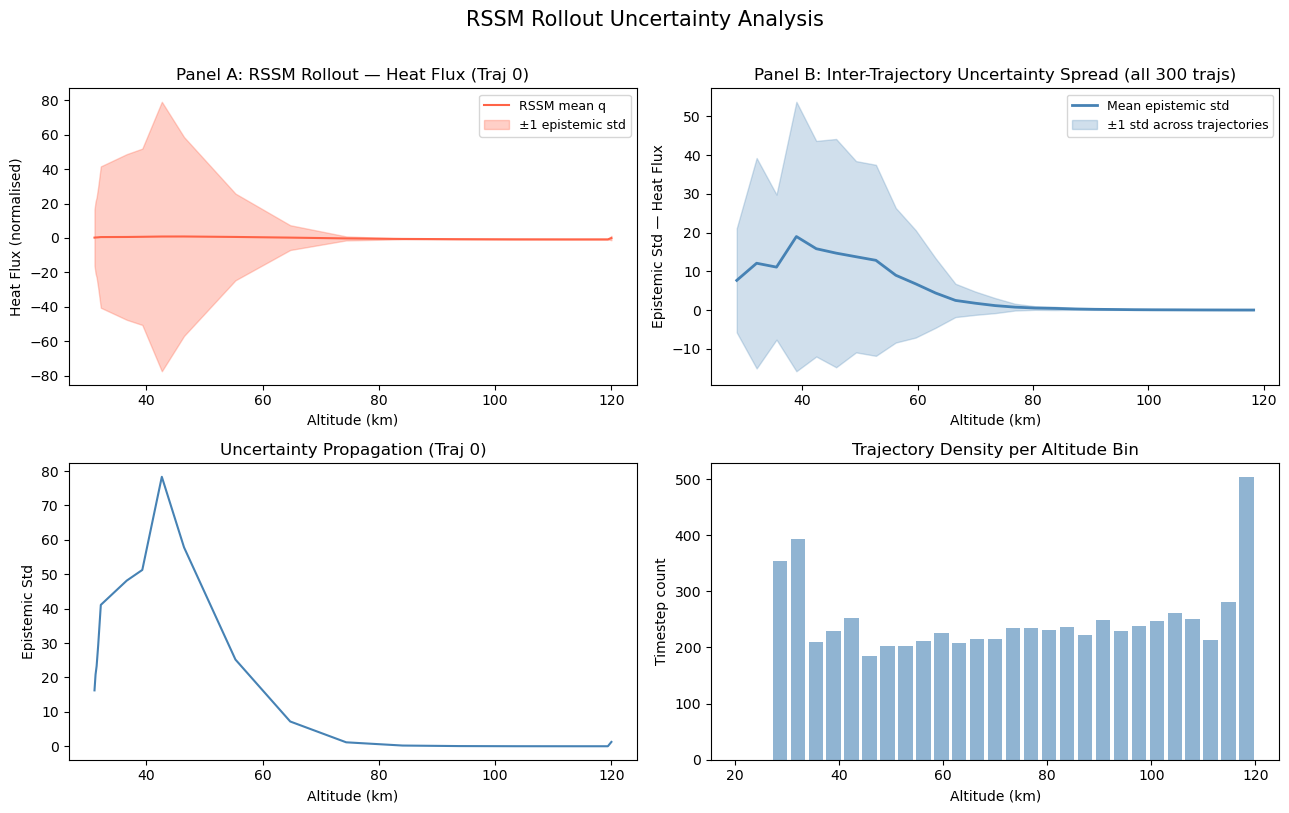

Peak mean uncertainty at: 39.0 km


In [7]:
# Cell 4 - RSSM Rollout: Single Trajectory + Inter-Trajectory Uncertainty Spread

rssm = SimplifiedRSSM(obs_dim=4, hidden_dim=64, latent_dim=32, out_dim=3)
rssm.load_state_dict(rssm_ckpt['model'])
rssm.eval()

X_mean_r = rssm_ckpt['X_mean']
X_std_r  = rssm_ckpt['X_std']

# ── Panel A: single trajectory rollout (trajectory 0) ──
traj0 = trajs[trajs['traj_id'] == 0].sort_values('time_s')
X_t0  = traj0[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
X_t0_norm = torch.tensor((X_t0 - X_mean_r) / X_std_r)

means0, ep_stds0 = rssm.rollout(X_t0_norm)
means0   = means0.numpy()
ep_stds0 = ep_stds0.numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ax = axes[0, 0]
ax.plot(traj0['altitude_km'].values, means0[:, 2], color='tomato', label='RSSM mean q')
ax.fill_between(traj0['altitude_km'].values,
                means0[:, 2] - ep_stds0[:, 2],
                means0[:, 2] + ep_stds0[:, 2],
                alpha=0.3, color='tomato', label='±1 epistemic std')
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Heat Flux (normalised)')
ax.set_title('Panel A: RSSM Rollout — Heat Flux (Traj 0)')
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(traj0['altitude_km'].values, ep_stds0[:, 2], color='steelblue')
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Epistemic Std')
ax.set_title('Uncertainty Propagation (Traj 0)')

# ── Panel B: inter-trajectory spread across all trajectories ──
ALT_BINS    = np.linspace(20, 120, 30)
bin_centers = 0.5 * (ALT_BINS[:-1] + ALT_BINS[1:])
bin_ep      = [[] for _ in range(len(bin_centers))]

with torch.no_grad():
    for tid in trajs['traj_id'].unique():
        traj = trajs[trajs['traj_id'] == tid].sort_values('time_s')
        if len(traj) < 2:
            continue
        X_raw  = traj[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
        X_norm = torch.tensor((X_raw - X_mean_r) / X_std_r)
        _, ep_stds = rssm.rollout(X_norm)
        ep_q = ep_stds.numpy()[:, 2]
        alts = traj['altitude_km'].values
        idxs = np.digitize(alts, ALT_BINS) - 1
        for j, bidx in enumerate(idxs):
            if 0 <= bidx < len(bin_centers):
                bin_ep[bidx].append(ep_q[j])

bin_mean = np.array([np.mean(b) if b else np.nan for b in bin_ep])
bin_std  = np.array([np.std(b)  if b else np.nan for b in bin_ep])
bin_n    = np.array([len(b) for b in bin_ep])

ax = axes[0, 1]
ax.plot(bin_centers, bin_mean, color='steelblue', linewidth=2, label='Mean epistemic std')
ax.fill_between(bin_centers,
                bin_mean - bin_std,
                bin_mean + bin_std,
                alpha=0.25, color='steelblue', label='±1 std across trajectories')
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Epistemic Std — Heat Flux')
ax.set_title('Panel B: Inter-Trajectory Uncertainty Spread (all 300 trajs)')
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.bar(bin_centers, bin_n, width=(ALT_BINS[1]-ALT_BINS[0])*0.8,
       color='steelblue', alpha=0.6)
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Timestep count')
ax.set_title('Trajectory Density per Altitude Bin')

plt.suptitle('RSSM Rollout Uncertainty Analysis', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../data/rssm_rollout_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak mean uncertainty at: {bin_centers[np.nanargmax(bin_mean)]:.1f} km')

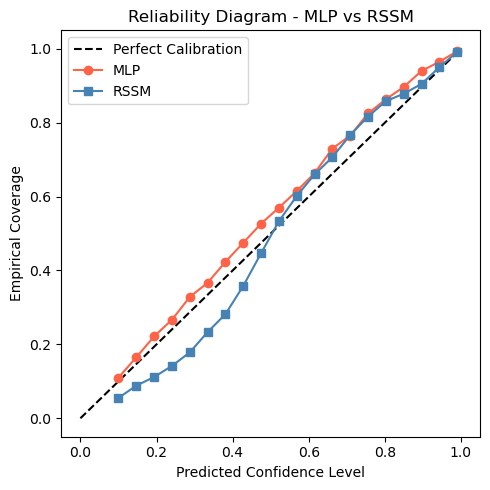

In [8]:
# Cell 5 - MLP vs RSSM Reliability

FEATURE_COLS = ['altitude_km', 'velocity_ms', 'alpha_deg', 'Twall_K']
TARGET_COLS = ['CL_mean', 'CD_mean', 'q_mean']
Y_raw = df[TARGET_COLS].values.astype(np.float32)
Y_mean_r = Y_raw.mean(0)
Y_std_r  = Y_raw.std(0)
Y_norm = torch.tensor((Y_raw - Y_mean_r) / Y_std_r)

X_mean_r = rssm_ckpt['X_mean']
X_std_r  = rssm_ckpt['X_std']

X_raw = df[FEATURE_COLS].values.astype(np.float32)
X_norm = torch.tensor((X_raw - X_mean_r) / X_std_r)

# --- MLP coverage (recomputed here) ---
Y_mean_m = mlp_ckpt['Y_mean']
Y_std_m  = mlp_ckpt['Y_std']
Y_raw_m  = df[['CL_mean','CD_mean','q_mean']].values.astype(np.float32)
Y_m      = torch.tensor((Y_raw_m - Y_mean_m) / Y_std_m)

confidence_levels = np.linspace(0.1, 0.99, 20)
empirical_coverage = []

with torch.no_grad():
    mu_mlp, v_mlp, alpha_mlp, beta_mlp = mlp(X)

from scipy.stats import t as student_t
for cl in confidence_levels:
    df_nig = 2 * alpha_mlp.numpy()
    scale  = (beta_mlp.numpy() * (1 + 1/v_mlp.numpy()) / alpha_mlp.numpy()) ** 0.5
    lo = mu_mlp.numpy() - student_t.ppf((1+cl)/2, df_nig) * scale
    hi = mu_mlp.numpy() + student_t.ppf((1+cl)/2, df_nig) * scale
    covered = ((Y_m.numpy() >= lo) & (Y_m.numpy() <= hi)).mean()
    empirical_coverage.append(covered)

# --- RSSM coverage ---
all_mu, all_v, all_alpha, all_beta = [], [], [], []
rssm.eval()
with torch.no_grad():
    for i in range(len(X_norm)):
        x_seq = X_norm[i].unsqueeze(0).unsqueeze(0)
        mu, v, alpha, beta, _ = rssm(x_seq)
        all_mu.append(mu.squeeze())
        all_v.append(v.squeeze())
        all_alpha.append(alpha.squeeze())
        all_beta.append(beta.squeeze())

mu_r    = torch.stack(all_mu).numpy()
v_r     = torch.stack(all_v).numpy()
alpha_r = torch.stack(all_alpha).numpy()
beta_r  = torch.stack(all_beta).numpy()
y_np    = Y_norm.numpy()

rssm_coverage = []
for cl in confidence_levels:
    df_nig = 2 * alpha_r
    scale  = (beta_r * (1 + 1/v_r) / alpha_r) ** 0.5
    lo = mu_r - student_t.ppf((1+cl)/2, df_nig) * scale
    hi = mu_r + student_t.ppf((1+cl)/2, df_nig) * scale
    covered = ((y_np >= lo) & (y_np <= hi)).mean()
    rssm_coverage.append(covered)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0,1],[0,1],'k--', label='Perfect Calibration')
ax.plot(confidence_levels, empirical_coverage, 'o-', color='tomato',    label='MLP')
ax.plot(confidence_levels, rssm_coverage,      's-', color='steelblue', label='RSSM')
ax.set_xlabel('Predicted Confidence Level')
ax.set_ylabel('Empirical Coverage')
ax.set_title('Reliability Diagram - MLP vs RSSM')
ax.legend()
plt.tight_layout()
plt.savefig('../data/calibration_comparison.png', dpi=150)
plt.show()

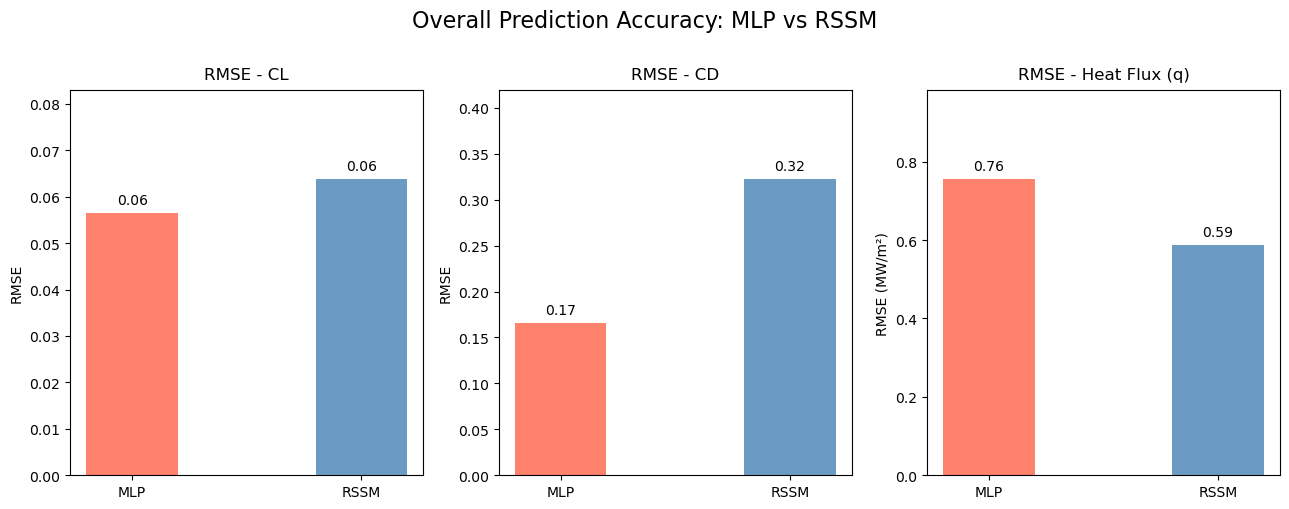

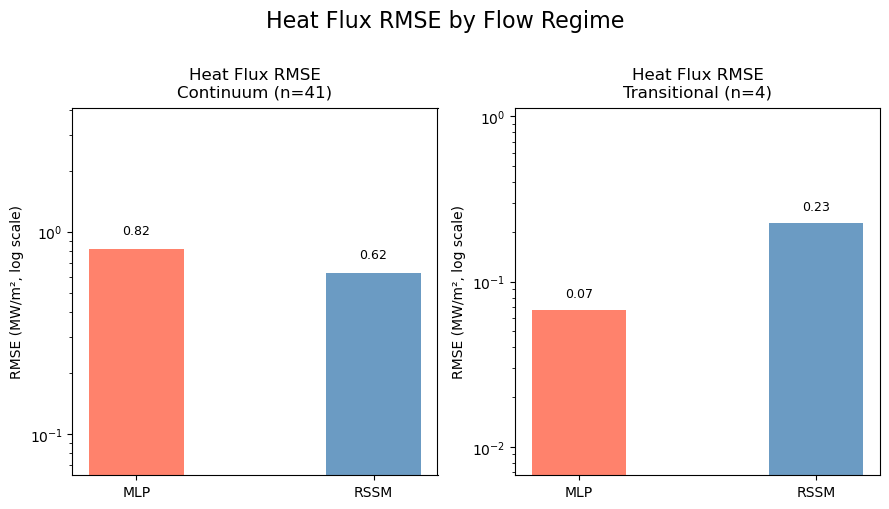


Regime                 MLP q RMSE (MW/m²)    RSSM q RMSE (MW/m²)    n
----------------------------------------------------------------------
Continuum                       0.823 ± 0.373              0.624 ± 0.501   41
Transitional                    0.067 ± 0.064              0.227 ± 0.031    4


In [9]:
# Cell 6 - MLP vs RSSM Prediction Accuracy (Overall + Regime-Conditioned)
FEATURE_COLS = ['altitude_km', 'velocity_ms', 'alpha_deg', 'Twall_K']
TARGET_COLS  = ['CL', 'CD', 'q']

traj_ids = trajs['traj_id'].unique()
np.random.seed(42)
np.random.shuffle(traj_ids)
n_val   = int(0.15 * len(traj_ids))
val_ids = traj_ids[:n_val]

X_mean_m, X_std_m = mlp_ckpt['X_mean'],  mlp_ckpt['X_std']
Y_mean_m, Y_std_m = mlp_ckpt['Y_mean'],  mlp_ckpt['Y_std']
X_mean_r, X_std_r = rssm_ckpt['X_mean'], rssm_ckpt['X_std']
Y_mean_r, Y_std_r = rssm_ckpt['Y_mean'], rssm_ckpt['Y_std']

mlp_errors  = {'all': [], 'continuum': [], 'transitional': []}
rssm_errors = {'all': [], 'continuum': [], 'transitional': []}

mlp.eval()
rssm.eval()

for tid in val_ids:
    traj = trajs[trajs['traj_id'] == tid].sort_values('time_s')
    if len(traj) < 2:
        continue

    alt_mean = traj['altitude_km'].mean()
    closest  = df.iloc[(df['altitude_km'] - alt_mean).abs().argsort()[:1]]
    regime   = closest['regime'].values[0]
    if regime not in mlp_errors:
        regime = 'transitional'

    X_raw = traj[FEATURE_COLS].values.astype(np.float32)
    Y_raw = traj[TARGET_COLS].values.astype(np.float32)

    X_m = torch.tensor((X_raw - X_mean_m) / X_std_m)
    with torch.no_grad():
        mu_m, _, _, _ = mlp(X_m)
    pred_m = mu_m.numpy() * Y_std_m + Y_mean_m
    err_m  = np.sqrt(((pred_m - Y_raw)**2).mean(axis=0))
    mlp_errors['all'].append(err_m)
    mlp_errors[regime].append(err_m)

    X_r = torch.tensor((X_raw - X_mean_r) / X_std_r).unsqueeze(0)
    with torch.no_grad():
        mu_r, _, _, _, _ = rssm(X_r)
    pred_r = mu_r.squeeze(0).numpy() * Y_std_r + Y_mean_r
    err_r  = np.sqrt(((pred_r - Y_raw)**2).mean(axis=0))
    rssm_errors['all'].append(err_r)
    rssm_errors[regime].append(err_r)

def get_stats(errors):
    arr = np.array(errors)
    return arr.mean(axis=0), arr.std(axis=0)

# --- Plot 1: Overall RMSE ---
mlp_mean,  mlp_std  = get_stats(mlp_errors['all'])
rssm_mean, rssm_std = get_stats(rssm_errors['all'])

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for i, (ax, label) in enumerate(zip(axes, ['CL', 'CD', 'Heat Flux (q)'])):
    scale = 1e6 if i == 2 else 1.0
    vals = [mlp_mean[i]/scale, rssm_mean[i]/scale]
    errs = [mlp_std[i]/scale,  rssm_std[i]/scale]
    bars = ax.bar(['MLP','RSSM'], vals,
                  color=['tomato','steelblue'], alpha=0.8, width=0.4)
    ymax = max(vals)
    ax.set_ylim(0, ymax * 1.30)
    unit = 'MW/m²' if i == 2 else '-'
    ax.set_title(f'RMSE - {label}', pad=8)
    ax.set_ylabel(f'RMSE ({unit})' if unit != '-' else 'RMSE')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + ymax * 0.02,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Overall Prediction Accuracy: MLP vs RSSM', y=1.01, fontsize=16)
plt.tight_layout()
plt.savefig('../data/rmse_overall.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Regime-conditioned heat flux ---
regimes      = ['continuum', 'transitional']
regime_label = ['Continuum', 'Transitional']

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for i, (regime, rlabel) in enumerate(zip(regimes, regime_label)):
    ax  = axes[i]
    m_e = mlp_errors[regime]
    r_e = rssm_errors[regime]
    n   = len(m_e)

    m_mean, m_std = get_stats(m_e)
    r_mean, r_std = get_stats(r_e)

    vals = [m_mean[2]/1e6, r_mean[2]/1e6]

    bars = ax.bar(['MLP','RSSM'], vals,
                  color=['tomato','steelblue'], alpha=0.8, width=0.4)
    ax.set_yscale('log')
    ax.set_title(f'Heat Flux RMSE\n{rlabel} (n={n})', pad=8)
    ax.set_ylabel('RMSE (MW/m², log scale)')
    ax.set_ylim(bottom=min(vals) * 0.1, top=max(vals) * 5)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.15,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Heat Flux RMSE by Flow Regime', y=1.01, fontsize=16)
plt.tight_layout()
plt.savefig('../data/rmse_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary table ---
print(f"\n{'Regime':<18} {'MLP q RMSE (MW/m²)':>22} {'RSSM q RMSE (MW/m²)':>22} {'n':>4}")
print("-" * 70)
for regime, rlabel in zip(regimes, regime_label):
    mm, ms = get_stats(mlp_errors[regime])
    rm, rs = get_stats(rssm_errors[regime])
    n = len(mlp_errors[regime])
    print(f"{rlabel:<18} {mm[2]/1e6:>18.3f} ± {ms[2]/1e6:<3.3f} "
          f"{rm[2]/1e6:>18.3f} ± {rs[2]/1e6:<3.3f} {n:>4}")

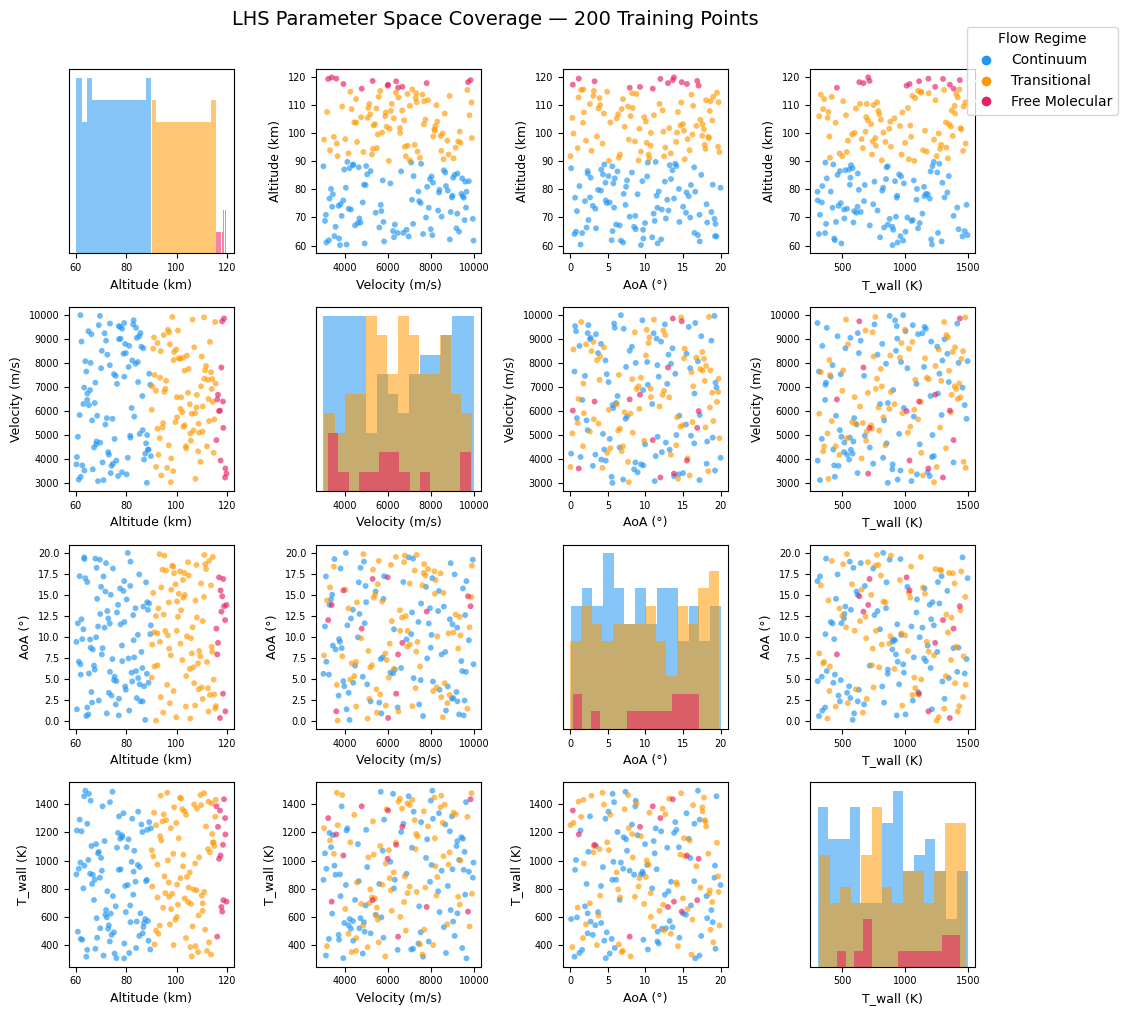

Regime breakdown: {'continuum': 100, 'transitional': 86, 'free_molecular': 14}


In [10]:
# Cell 7 - LHS Parameter Space Coverage

PALETTE = {
    'continuum':      '#2196F3',
    'transitional':   '#FF9800',
    'free_molecular': '#E91E63',
}
REGIME_ORDER = ['continuum', 'transitional', 'free_molecular']

params = {
    'altitude_km': 'Altitude (km)',
    'velocity_ms': 'Velocity (m/s)',
    'alpha_deg':   'AoA (°)',
    'Twall_K':     'T_wall (K)',
}
keys   = list(params.keys())
labels = list(params.values())
n      = len(keys)

fig, axes = plt.subplots(n, n, figsize=(10, 10))
fig.suptitle('LHS Parameter Space Coverage — 200 Training Points',
             fontsize=14, y=1.01)

for r in range(n):
    for c in range(n):
        ax = axes[r, c]
        if r == c:
            for regime in REGIME_ORDER:
                sub = df[df['regime'] == regime]
                ax.hist(sub[keys[r]], bins=14, alpha=0.55,
                        color=PALETTE[regime],
                        label=regime.replace('_', ' ').title())
            ax.set_xlabel(labels[r], fontsize=9)
            ax.set_yticks([])
        else:
            for regime in REGIME_ORDER:
                sub = df[df['regime'] == regime]
                ax.scatter(sub[keys[c]], sub[keys[r]],
                           s=18, alpha=0.65,
                           color=PALETTE[regime], edgecolors='none')
            ax.set_xlabel(labels[c], fontsize=9)
            ax.set_ylabel(labels[r], fontsize=9)
        ax.tick_params(labelsize=7)

handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=PALETTE[r], markersize=8,
               label=r.replace('_',' ').title())
    for r in REGIME_ORDER
]
fig.legend(handles=handles, loc='upper right',
           bbox_to_anchor=(1.13, 1.0), fontsize=10,
           title='Flow Regime', title_fontsize=10)

plt.tight_layout()
plt.savefig('../data/lhs_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Regime breakdown: {df['regime'].value_counts().to_dict()}")

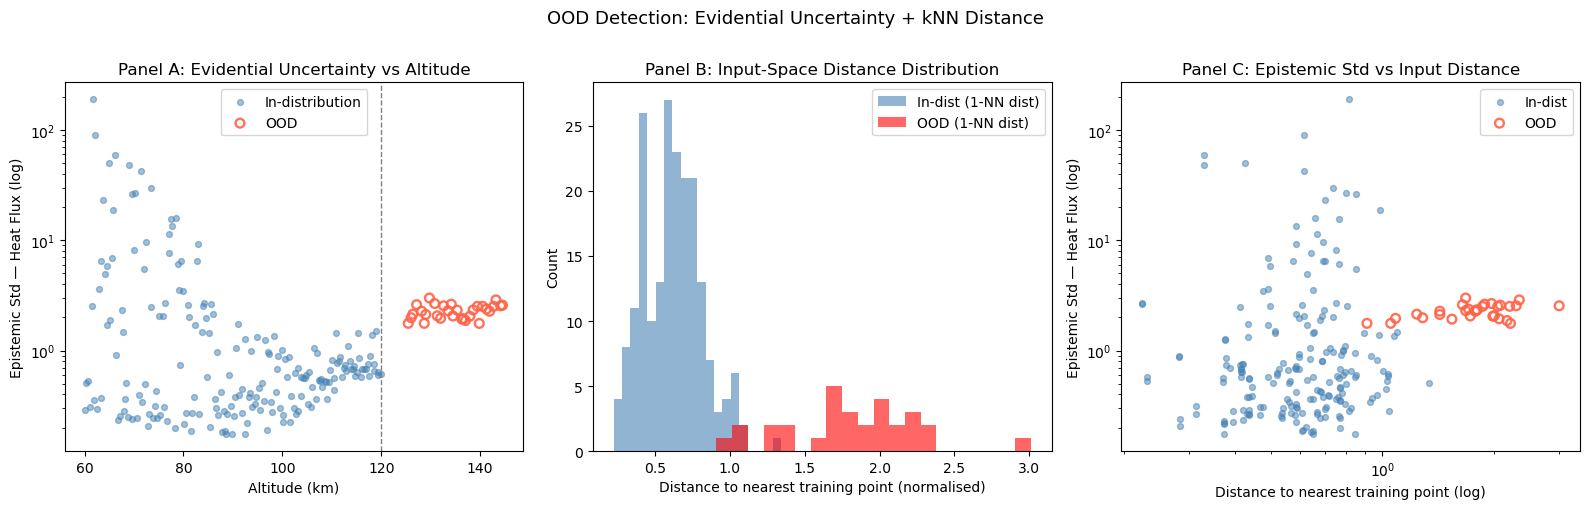

Mean OOD epistemic std:          2.2759
Mean in-dist epistemic std:      4.3922
OOD/in-dist epistemic ratio:     0.52x
Mean in-dist 1-NN distance:      0.621
Mean OOD 1-NN distance:          1.802
OOD/in-dist distance ratio:      2.90x


In [11]:
# Cell 8 - OOD Detection: Evidential Uncertainty + kNN Distance

import os
from sklearn.neighbors import NearestNeighbors

OOD_PATH = '../data/ood_processed.parquet'
assert os.path.exists(OOD_PATH), 'Run the OOD pipeline scripts first.'

df_ood    = pd.read_parquet(OOD_PATH)
X_ood_raw = df_ood[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
X_ood     = torch.tensor((X_ood_raw - mlp_ckpt['X_mean']) / mlp_ckpt['X_std'])

with torch.no_grad():
    mu_ood, v_ood, alpha_ood, beta_ood = mlp(X_ood)
    ep_var_ood = beta_ood / (v_ood * (alpha_ood - 1).clamp(min=1e-4))
    ep_std_ood = ep_var_ood.sqrt().numpy()

# kNN distances in normalized input space
X_in_np  = torch.tensor((df[['altitude_km','velocity_ms','alpha_deg','Twall_K']].values.astype(np.float32)
                          - mlp_ckpt['X_mean']) / mlp_ckpt['X_std']).numpy()
X_ood_np = X_ood.numpy()

nbrs         = NearestNeighbors(n_neighbors=2).fit(X_in_np)
dist_in,  _  = nbrs.kneighbors(X_in_np)
dist_ood, _  = nbrs.kneighbors(X_ood_np)
dist_in_1nn  = dist_in[:,  1]   # col 0 is self-match
dist_ood_1nn = dist_ood[:, 0]

colors_r = {'continuum':'#2196F3', 'transitional':'#FF9800', 'free_molecular':'#E91E63'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: epistemic std vs altitude
ax = axes[0]
ax.scatter(df['altitude_km'], df['ep_std_q_mlp'],
           s=18, alpha=0.5, color='steelblue', label='In-distribution')
ax.scatter(df_ood['altitude_km'], ep_std_ood[:, 2],
           s=40, alpha=0.9, color='none', edgecolors='tomato',
           linewidths=1.7, marker='o', label='OOD')
ax.axvline(120, color='gray', linestyle='--', linewidth=1)
ax.set_yscale('log')
ax.set_xlabel('Altitude (km)')
ax.set_ylabel('Epistemic Std — Heat Flux (log)')
ax.set_title('Panel A: Evidential Uncertainty vs Altitude')
ax.legend()

# Panel B: kNN distance distribution
ax = axes[1]
ax.hist(dist_in_1nn,  bins=20, alpha=0.6, color='steelblue', label='In-dist (1-NN dist)')
ax.hist(dist_ood_1nn, bins=20, alpha=0.6, color='red',       label='OOD (1-NN dist)')
ax.set_xlabel('Distance to nearest training point (normalised)')
ax.set_ylabel('Count')
ax.set_title('Panel B: Input-Space Distance Distribution')
ax.legend()

# Panel C: epistemic std vs kNN distance (both in-dist and OOD)
ax = axes[2]
ax.scatter(dist_in_1nn,  df['ep_std_q_mlp'], s=18, alpha=0.5,
           color='steelblue', label='In-dist')
ax.scatter(dist_ood_1nn, ep_std_ood[:, 2],   s=40, alpha=0.9,
           color='none', edgecolors='tomato',
           linewidths=1.7, marker='o', label='OOD')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Distance to nearest training point (log)')
ax.set_ylabel('Epistemic Std — Heat Flux (log)')
ax.set_title('Panel C: Epistemic Std vs Input Distance')
ax.legend()

plt.suptitle('OOD Detection: Evidential Uncertainty + kNN Distance', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/ood_detection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean OOD epistemic std:          {ep_std_ood[:,2].mean():.4f}')
print(f'Mean in-dist epistemic std:      {df["ep_std_q_mlp"].mean():.4f}')
print(f'OOD/in-dist epistemic ratio:     {ep_std_ood[:,2].mean()/df["ep_std_q_mlp"].mean():.2f}x')
print(f'Mean in-dist 1-NN distance:      {dist_in_1nn.mean():.3f}')
print(f'Mean OOD 1-NN distance:          {dist_ood_1nn.mean():.3f}')
print(f'OOD/in-dist distance ratio:      {dist_ood_1nn.mean()/dist_in_1nn.mean():.2f}x')

Val trajectory lengths — min: 14, max: 45, mean: 23
Horizon   1: 45 windows
Horizon   5: 45 windows
Horizon  10: 45 windows
Horizon  20: 25 windows


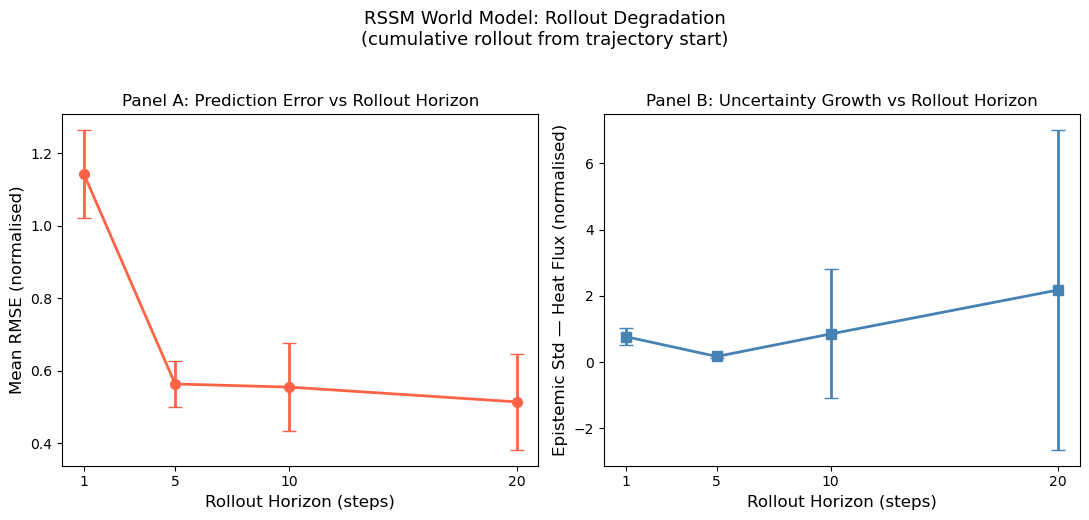


   Horizon       RMSE     Ep.Std  n windows
--------------------------------------------
         1      1.1422     0.7698         45
         5      0.5638     0.1701         45
        10      0.5553     0.8508         45
        20      0.5145     2.1798         25


In [12]:
# Cell 9 - RSSM Multi-Step Rollout Degradation

FEATURE_COLS = ['altitude_km', 'velocity_ms', 'alpha_deg', 'Twall_K']
TARGET_COLS  = ['CL', 'CD', 'q']
HORIZONS     = [1, 5, 10, 20]

traj_ids = trajs['traj_id'].unique()
np.random.seed(42)
np.random.shuffle(traj_ids)
val_ids = traj_ids[:int(0.15 * len(traj_ids))]

X_mean_r, X_std_r = rssm_ckpt['X_mean'], rssm_ckpt['X_std']
Y_mean_r, Y_std_r = rssm_ckpt['Y_mean'], rssm_ckpt['Y_std']

horizon_rmse  = {k: [] for k in HORIZONS}
horizon_epstd = {k: [] for k in HORIZONS}

traj_lengths = []
for tid in val_ids:
    traj = trajs[trajs['traj_id'] == tid]
    traj_lengths.append(len(traj))
print(f'Val trajectory lengths — min: {min(traj_lengths)}, max: {max(traj_lengths)}, mean: {np.mean(traj_lengths):.0f}')

rssm.eval()
with torch.no_grad():
    for tid in val_ids:
        traj = trajs[trajs['traj_id'] == tid].sort_values('time_s')
        X_raw = traj[FEATURE_COLS].values.astype(np.float32)
        Y_raw = traj[TARGET_COLS].values.astype(np.float32)
        T     = len(X_raw)

        # Cumulative rollout from trajectory start — tests compounding error
        for k in HORIZONS:
            if T < k + 1:
                continue
            X_norm     = torch.tensor((X_raw[:k] - X_mean_r) / X_std_r)
            mu, ep_s   = rssm.rollout(X_norm)
            Y_raw_norm = (Y_raw[:k] - Y_mean_r) / Y_std_r
            horizon_rmse[k].append(np.sqrt(((mu.numpy() - Y_raw_norm)**2).mean()))
            horizon_epstd[k].append(ep_s.numpy()[:, 2].mean())

for k in HORIZONS:
    print(f'Horizon {k:>3}: {len(horizon_rmse[k])} windows')

rmse_means  = [np.nanmean(horizon_rmse[k]) if horizon_rmse[k] else np.nan for k in HORIZONS]
rmse_stds   = [np.nanstd(horizon_rmse[k])  if horizon_rmse[k] else np.nan for k in HORIZONS]
epstd_means = [np.nanmean(horizon_epstd[k]) if horizon_epstd[k] else np.nan for k in HORIZONS]
epstd_stds  = [np.nanstd(horizon_epstd[k])  if horizon_epstd[k] else np.nan for k in HORIZONS]

valid   = [i for i, v in enumerate(rmse_means) if not np.isnan(v)]
h_plot  = [HORIZONS[i]    for i in valid]
rm_plot = [rmse_means[i]  for i in valid]
rs_plot = [rmse_stds[i]   for i in valid]
em_plot = [epstd_means[i] for i in valid]
es_plot = [epstd_stds[i]  for i in valid]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
ax.errorbar(h_plot, rm_plot, yerr=rs_plot,
            fmt='o-', color='tomato', capsize=5, linewidth=2, markersize=7)
ax.set_xlabel('Rollout Horizon (steps)', fontsize=12)
ax.set_ylabel('Mean RMSE (normalised)', fontsize=12)
ax.set_title('Panel A: Prediction Error vs Rollout Horizon', fontsize=12)
ax.set_xticks(h_plot)

ax = axes[1]
ax.errorbar(h_plot, em_plot, yerr=es_plot,
            fmt='s-', color='steelblue', capsize=5, linewidth=2, markersize=7)
ax.set_xlabel('Rollout Horizon (steps)', fontsize=12)
ax.set_ylabel('Epistemic Std — Heat Flux (normalised)', fontsize=12)
ax.set_title('Panel B: Uncertainty Growth vs Rollout Horizon', fontsize=12)
ax.set_xticks(h_plot)

plt.suptitle('RSSM World Model: Rollout Degradation\n'
             '(cumulative rollout from trajectory start)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('../data/rssm_rollout_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Horizon":>10} {"RMSE":>10} {"Ep.Std":>10} {"n windows":>10}')
print('-'*44)
for k, rm, em in zip(h_plot, rm_plot, em_plot):
    print(f'{k:>10}  {rm:>10.4f} {em:>10.4f} {len(horizon_rmse[k]):>10}')